# Census Income Segmentation Model

### **1. Imports & Data Loading:**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from category_encoders import TargetEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load columns
with open('/kaggle/input/datasets/nikhilram9/census-income-project/census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f.readlines()]

# Load data
df = pd.read_csv('/kaggle/input/datasets/nikhilram9/census-income-project/census-bureau.data',
                 header=None,
                 names=columns)

print(f"Dataset shape: {df.shape}")

Dataset shape: (199523, 42)


### **2. Data Cleaning:**

In [34]:
# Remove minors
df = df[df['age'] >= 18].reset_index(drop=True)

# Drop useless columns
cols_to_drop = [
    'migration code-change in msa',
    'migration code-change in reg',
    'migration code-move within reg',
    'migration prev res in sunbelt',
    'family members under 18'
]
df = df.drop(columns=cols_to_drop)

# Replace ? with Unknown
cols_with_question = [
    'state of previous residence',
    'country of birth father',
    'country of birth mother',
    'country of birth self'
]
for col in cols_with_question:
    df[col] = df[col].replace('?', 'Unknown')

df['hispanic origin'] = df['hispanic origin'].fillna('Unknown')

# Encode label
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})

# Fix column types
to_categorical = [
    'own business or self employed',
    'veterans benefits',
    'year',
    'detailed industry recode',
    'detailed occupation recode'
]
for col in to_categorical:
    df[col] = df[col].astype(str)

print(f"Clean dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

Clean dataset shape: (143531, 37)
Label distribution:
label
0    131151
1     12380
Name: count, dtype: int64


### **3. Dataset Preparation:**

In [35]:
# Full adult population for broad segmentation
df_full = df.drop(columns=['label', 'weight'])

# High earners only for premium segmentation
df_high = df[df['label'] == 1].drop(columns=['label', 'weight'])

print(f"Full adult population: {df_full.shape}")
print(f"High earners only: {df_high.shape}")

Full adult population: (143531, 35)
High earners only: (12380, 35)


### **4. Encoding & Scaling:**

In [36]:
# Identify column types
numerical_cols = df_full.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_full.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (7): ['age', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'num persons worked for employer', 'weeks worked in year']
Categorical columns (28): ['class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'year']


In [37]:
# For full population - use income label for target encoding
te_full = TargetEncoder(cols=categorical_cols)
df_full_encoded = te_full.fit_transform(df_full, df['label'])

# For high earners - use weeks worked as proxy target (no label variation within high earners)
df_high_source = df[df['label'] == 1].drop(columns=['label', 'weight'])
te_high = TargetEncoder(cols=categorical_cols)
df_high_encoded = te_high.fit_transform(df_high_source, df[df['label'] == 1]['weeks worked in year'])

# Scale both datasets
scaler_full = StandardScaler()
df_full_scaled = scaler_full.fit_transform(df_full_encoded)

scaler_high = StandardScaler()
df_high_scaled = scaler_high.fit_transform(df_high_encoded)

print(f"Full population encoded and scaled: {df_full_scaled.shape}")
print(f"High earners encoded and scaled: {df_high_scaled.shape}")

Full population encoded and scaled: (143531, 35)
High earners encoded and scaled: (12380, 35)


### **5. Dimensionality Reduction (PCA):**

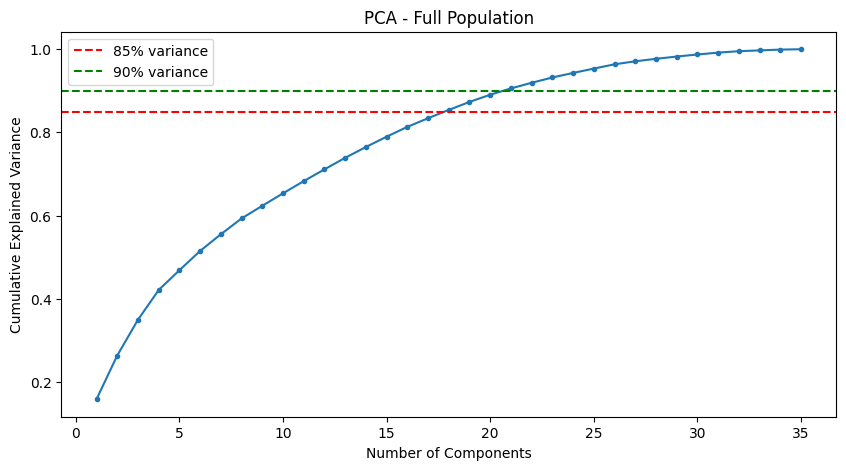

Components needed for 85% variance: 18
Components needed for 90% variance: 21


In [38]:
# Apply PCA to full population
pca_full = PCA(random_state=42)
pca_full.fit(df_full_scaled)

# Plot explained variance
plt.figure(figsize=(10, 5))
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
plt.axhline(y=0.85, color='red', linestyle='--', label='85% variance')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Full Population')
plt.legend()
plt.show()

# Find components needed for 85% and 90% variance
n_85 = (cumulative_variance >= 0.85).argmax() + 1
n_90 = (cumulative_variance >= 0.90).argmax() + 1
print(f"Components needed for 85% variance: {n_85}")
print(f"Components needed for 90% variance: {n_90}")

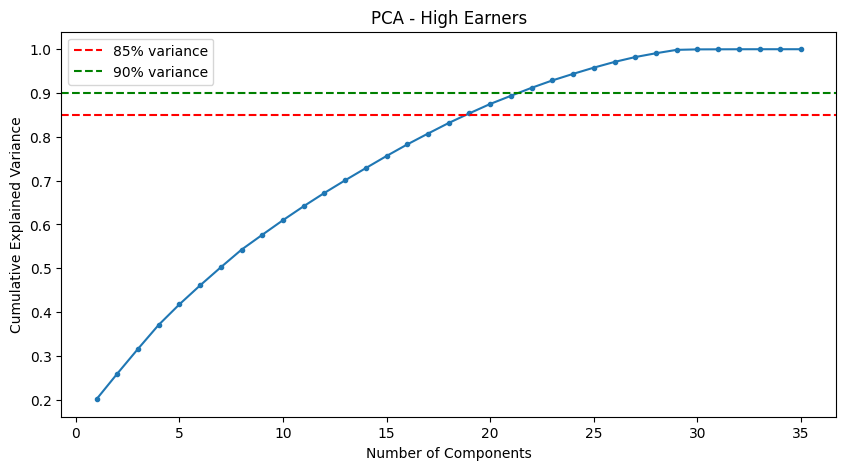

Components needed for 85% variance: 19
Components needed for 90% variance: 22


In [39]:
# Apply PCA to high earners
pca_high = PCA(random_state=42)
pca_high.fit(df_high_scaled)

# Plot explained variance
plt.figure(figsize=(10, 5))
cumulative_variance_high = pca_high.explained_variance_ratio_.cumsum()
plt.plot(range(1, len(cumulative_variance_high) + 1), cumulative_variance_high, marker='o', markersize=3)
plt.axhline(y=0.85, color='red', linestyle='--', label='85% variance')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - High Earners')
plt.legend()
plt.show()

n_85_high = (cumulative_variance_high >= 0.85).argmax() + 1
n_90_high = (cumulative_variance_high >= 0.90).argmax() + 1
print(f"Components needed for 85% variance: {n_85_high}")
print(f"Components needed for 90% variance: {n_90_high}")

In [40]:
# Apply PCA with chosen components
pca_full_final = PCA(n_components=18, random_state=42)
df_full_pca = pca_full_final.fit_transform(df_full_scaled)

pca_high_final = PCA(n_components=19, random_state=42)
df_high_pca = pca_high_final.fit_transform(df_high_scaled)

print(f"Full population after PCA: {df_full_pca.shape}")
print(f"High earners after PCA: {df_high_pca.shape}")

Full population after PCA: (143531, 18)
High earners after PCA: (12380, 19)


### **6. Optimal Cluster Selection:**

k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done
k=9 done
k=10 done


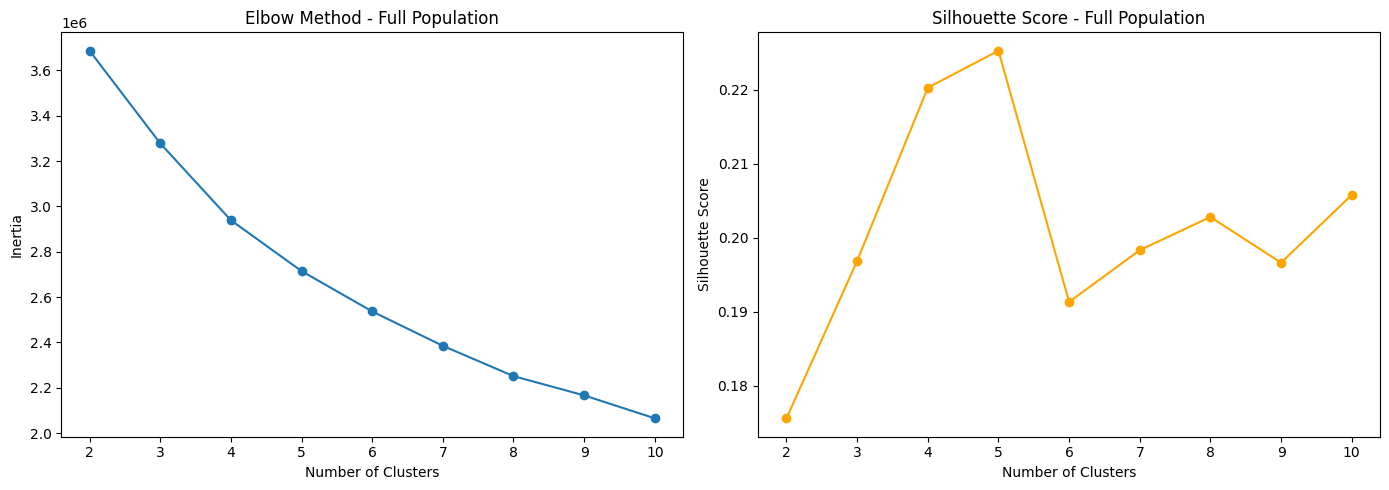


Silhouette Scores:
k=2: 0.1756
k=3: 0.1969
k=4: 0.2203
k=5: 0.2253
k=6: 0.1913
k=7: 0.1983
k=8: 0.2028
k=9: 0.1966
k=10: 0.2058


In [41]:
# Find optimal clusters for full population
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_full_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_full_pca, labels, sample_size=10000, random_state=42))
    print(f"k={k} done")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method - Full Population')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score - Full Population')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: {s:.4f}")

k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done
k=9 done
k=10 done


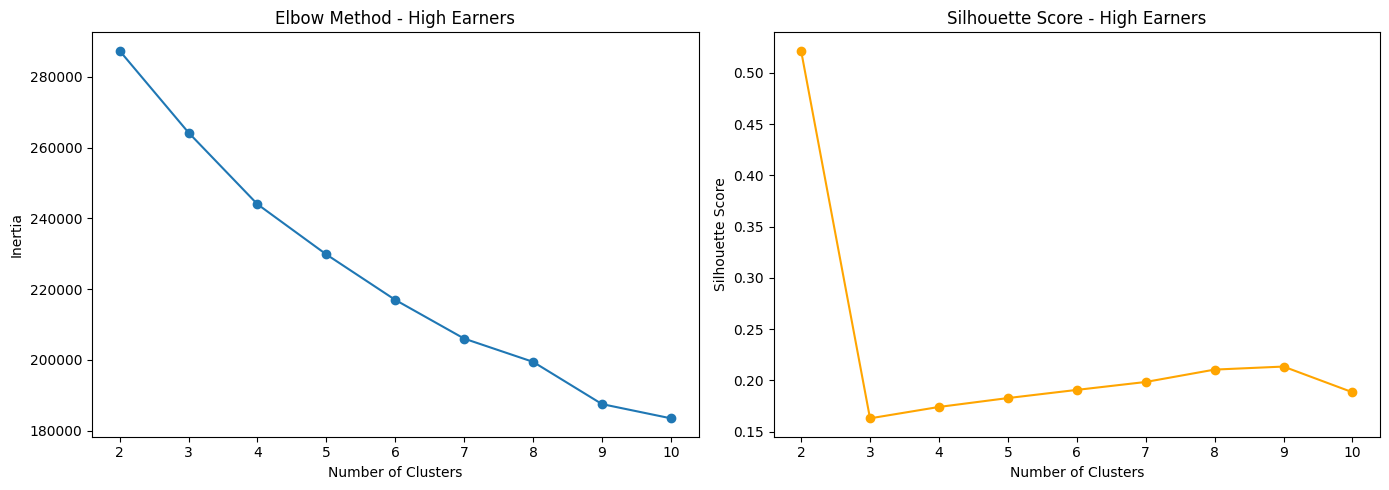


Silhouette Scores:
k=2: 0.5216
k=3: 0.1630
k=4: 0.1741
k=5: 0.1828
k=6: 0.1907
k=7: 0.1985
k=8: 0.2106
k=9: 0.2135
k=10: 0.1885


In [42]:
# Find optimal clusters for high earners
inertias_high = []
silhouette_scores_high = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_high_pca)
    inertias_high.append(kmeans.inertia_)
    silhouette_scores_high.append(silhouette_score(df_high_pca, labels, random_state=42))
    print(f"k={k} done")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias_high, marker='o')
axes[0].set_title('Elbow Method - High Earners')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores_high, marker='o', color='orange')
axes[1].set_title('Silhouette Score - High Earners')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(k_range, silhouette_scores_high):
    print(f"k={k}: {s:.4f}")

### **7. Clustering:**

In [43]:
# Final clustering - Full population
kmeans_full = KMeans(n_clusters=5, random_state=42, n_init=10)
full_labels = kmeans_full.fit_predict(df_full_pca)

# Final clustering - High earners
kmeans_high = KMeans(n_clusters=2, random_state=42, n_init=10)
high_labels = kmeans_high.fit_predict(df_high_pca)

# Add cluster labels back to original dataframes
df_full_clustered = df_full.copy()
df_full_clustered['cluster'] = full_labels

df_high_clustered = df_high_source.copy()
df_high_clustered['cluster'] = high_labels

print("Full population cluster distribution:")
print(df_full_clustered['cluster'].value_counts().sort_index())
print("\nHigh earners cluster distribution:")
print(df_high_clustered['cluster'].value_counts().sort_index())

Full population cluster distribution:
cluster
0    44335
1    10867
2     1591
3     9839
4    76899
Name: count, dtype: int64

High earners cluster distribution:
cluster
0      906
1    11474
Name: count, dtype: int64


### **8. Cluster Profiling & Interpretation:**

In [44]:
# Profile full population clusters
profile_full = df_full_clustered.groupby('cluster').agg({
    'age': 'mean',
    'education': lambda x: x.mode()[0],
    'sex': lambda x: x.mode()[0],
    'marital stat': lambda x: x.mode()[0],
    'major occupation code': lambda x: x.mode()[0],
    'weeks worked in year': 'mean',
    'wage per hour': 'mean',
    'capital gains': 'mean',
    'dividends from stocks': 'mean',
    'class of worker': lambda x: x.mode()[0],
}).round(2)

profile_full['size'] = df_full_clustered['cluster'].value_counts().sort_index()
profile_full['size_pct'] = (profile_full['size'] / len(df_full_clustered) * 100).round(1)

print(profile_full.to_string())

           age             education     sex                     marital stat   major occupation code  weeks worked in year  wage per hour  capital gains  dividends from stocks  class of worker   size  size_pct
cluster                                                                                                                                                                                                           
0        55.83  High school graduate  Female  Married-civilian spouse present         Not in universe                  4.80           2.34         215.81                 402.48  Not in universe  44335      30.9
1        37.98  High school graduate  Female  Married-civilian spouse present         Not in universe                 28.47          44.39         146.31                  19.38          Private  10867       7.6
2        59.49  High school graduate    Male  Married-civilian spouse present         Not in universe                 20.19          47.77         577.86   

In [45]:
# Profile high earner clusters
profile_high = df_high_clustered.groupby('cluster').agg({
    'age': 'mean',
    'education': lambda x: x.mode()[0],
    'sex': lambda x: x.mode()[0],
    'marital stat': lambda x: x.mode()[0],
    'major occupation code': lambda x: x.mode()[0],
    'weeks worked in year': 'mean',
    'wage per hour': 'mean',
    'capital gains': 'mean',
    'dividends from stocks': 'mean',
    'class of worker': lambda x: x.mode()[0],
}).round(2)

profile_high['size'] = df_high_clustered['cluster'].value_counts().sort_index()
profile_high['size_pct'] = (profile_high['size'] / len(df_high_clustered) * 100).round(1)

print(profile_high.to_string())

           age                   education   sex                     marital stat           major occupation code  weeks worked in year  wage per hour  capital gains  dividends from stocks  class of worker   size  size_pct
cluster                                                                                                                                                                                                                       
0        63.22  Bachelors degree(BA AB BS)  Male  Married-civilian spouse present                 Not in universe                 13.71            0.0        4103.19                6656.86  Not in universe    906       7.3
1        44.93  Bachelors degree(BA AB BS)  Male  Married-civilian spouse present  Executive admin and managerial                 50.78           88.1        4889.24                1150.75          Private  11474      92.7


#### Full Population Segment Names
- Cluster 0: Retired & Inactive Homemakers
- Cluster 1: Part-time Workers  
- Cluster 2: Wealthy Inactive/Investors
- Cluster 3: Mid-level Workers
- Cluster 4: Working Professionals

#### High Earner Segment Names
- Cluster 0: Wealthy Investors & Retirees
- Cluster 1: High Earning Professionals

### **9. Visualization:**

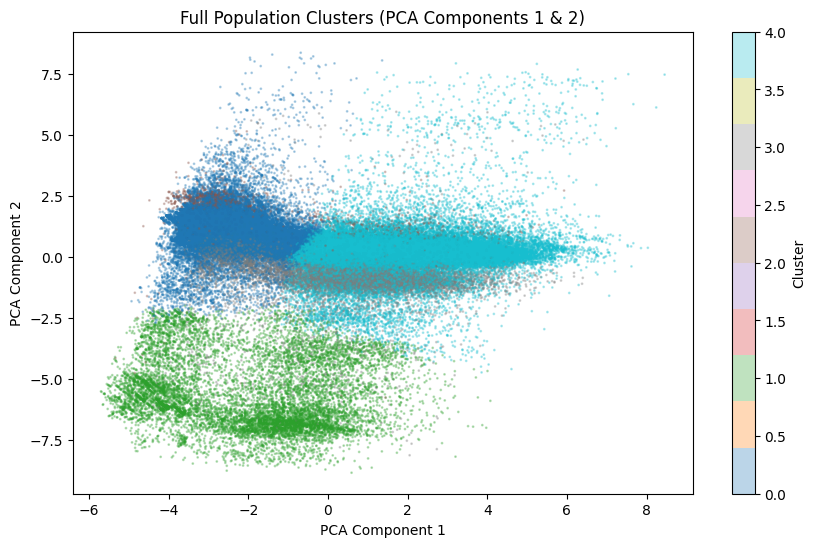

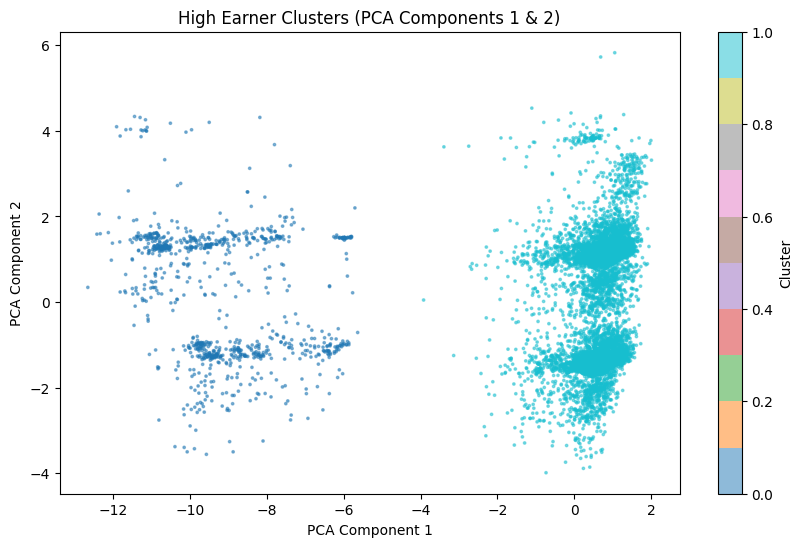

In [46]:
# Visualize full population clusters using first 2 PCA components
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_full_pca[:, 0], df_full_pca[:, 1], 
                      c=full_labels, cmap='tab10', alpha=0.3, s=1)
plt.colorbar(scatter, label='Cluster')
plt.title('Full Population Clusters (PCA Components 1 & 2)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# Visualize high earner clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_high_pca[:, 0], df_high_pca[:, 1],
                      c=high_labels, cmap='tab10', alpha=0.5, s=3)
plt.colorbar(scatter, label='Cluster')
plt.title('High Earner Clusters (PCA Components 1 & 2)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

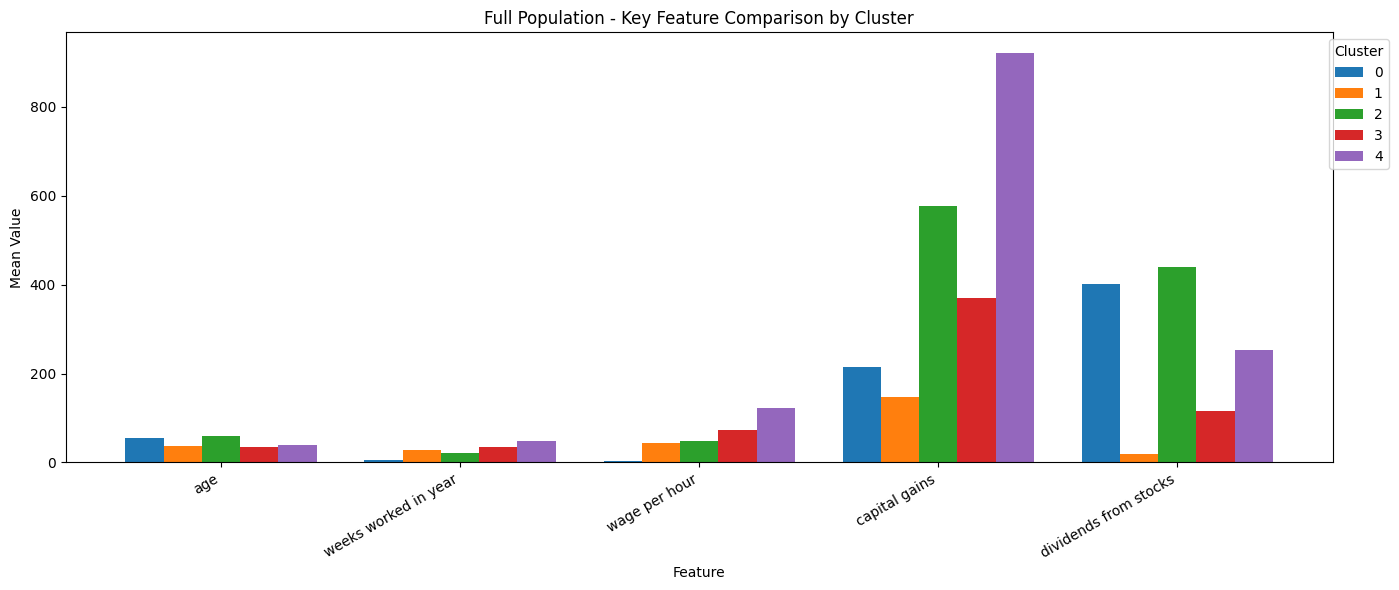

In [47]:
# Key features comparison across full population clusters
key_features = ['age', 'weeks worked in year', 'wage per hour', 
                'capital gains', 'dividends from stocks']

cluster_means = df_full_clustered.groupby('cluster')[key_features].mean()

cluster_means.T.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('Full Population - Key Feature Comparison by Cluster')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

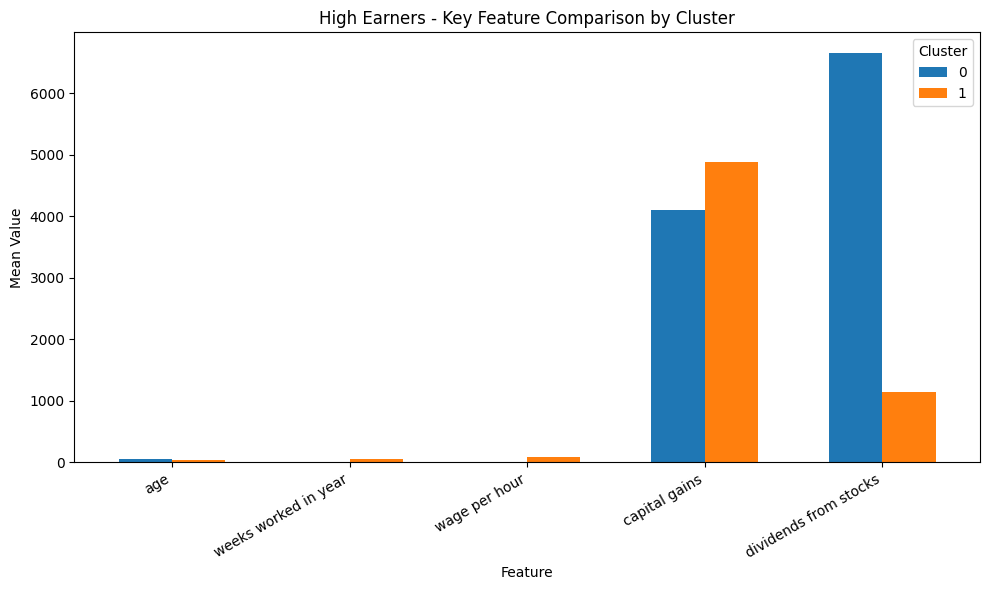

In [48]:
# Key features comparison across high earner clusters
cluster_means_high = df_high_clustered.groupby('cluster')[key_features].mean()

cluster_means_high.T.plot(kind='bar', figsize=(10, 6), width=0.6)
plt.title('High Earners - Key Feature Comparison by Cluster')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()